# Regresión Lineal Múltiple 

El modelo de regresión lineal múltiple puede expresarse en forma matricial como:

$$
\mathbf{Y} = \mathbf{X}\boldsymbol{\beta} + \boldsymbol{\varepsilon}
$$

donde:  

- $\mathbf{Y}$ es el vector de observaciones de la variable dependiente, de dimensión $n \times 1$;
- $\mathbf{X}$ es la matriz de diseño o de regresores, de dimensión $n \times p$, que contiene una columna de unos (para el intercepto) y las columnas correspondientes a las variables explicativas;
- $\boldsymbol{\beta}$ es el vector de coeficientes del modelo, de dimensión $p \times 1$;
- $\boldsymbol{\varepsilon}$ es el vector de errores aleatorios, con $E(\boldsymbol{\varepsilon}) = \mathbf{0}$ y $Var(\boldsymbol{\varepsilon}) = \sigma^2 \mathbf{I}_n$.


Definiremos algunos conceptos importantes para la parte práctica de la regresión lineal múltiple.

## Modelos


- **Modelo de efectos principales**

El modelo de efectos principales incluye únicamente los efectos individuales de cada variable explicativa sobre la variable de respuesta, sin considerar interacciones entre ellas.

Si existen dos variables explicativas $x_1$ y $x_2$, el modelo se expresa como:



$$
\mathbb{E}(y | x_{1},x_{2})= \beta_0 + \beta_1 x_{1} + \beta_2 x_{2}
$$


- **Modelo con interacción entre variables**

Una interacción entre variables ocurre cuando el efecto de una variable explicativa sobre la variable de respuesta depende del nivel de otra variable. 

Es decir, si el efecto de $x_1$ sobre $\mathbb{E}(y | x_{1},x_{2})$ varía según los valores de $x_2$, se dice que existe una interacción entre $x_1$ y $x_2$.

El modelo con interacción entre dos variables es:

$$
\mathbb{E}(y | x_{1},x_{2}) = \beta_0 + \beta_1 x_{1} + \beta_2 x_{2} + \beta_{3}(x_{1}x_{2})
$$

donde el término $x_{1}x_{2}$ representa la interacción entre $x_1$ y $x_2$.

*Ejemplo:* Si $x_1$ es continua y $x_2$ es categórica con niveles "A" y "B", y se agrega la interacción $x_{1}x_{2}$, el modelo general se convierte en:

$$
\mathbb{E}(y | x_{1},x_{2}) = \beta_0 + \beta_1 x_{1} + \beta_2 I(x_{2} = B) + \beta_{3}(x_{1}I(x_{2} = B))
$$

donde $I(x_{2} = B)$ es una variable indicadora que toma el valor 1 si $x_2$ es "B" y 0 si es "A".

Se puede apreciar que el efecto de $x_{1}x_{2}$ en $\mathbb{E}(y | x_{1},x_{2})$ depende del nivel de $x_2$, por lo que el efecto de $x_1$ sobre $\mathbb{E}(y | x_{1},x_{2})$ depende del valor de $x_2$.

- **Modelo saturado**

El modelo saturado es aquel que incluye todos los efectos posibles: el intercepto, los efectos principales y todas las interacciones de primer, segundo y hasta el orden máximo posible según las variables disponibles.

Este modelo captura todas las relaciones posibles entre las variables explicativas y la variable de respuesta, por lo que puede ser computacionalmente costoso, además de **ajustarse perfectamente a los datos de entrenamiento**, pero tendrá problemas ajustando a datos nuevos debido al **sobreajuste**. 

**Es decir, el modelo saturado modela mis datos, no el fenómeno subyacente.**

Suele utilizarse como referencia para comparar otros modelos más simples.


Para dos variables $x_1$ y $x_2$ continuas, el modelo saturado coincide con el modelo con interacción de primer orden:

$$
\mathbb{E}(y | x_{1},x_{2}) = \beta_0 + \beta_1 x_{1} + \beta_2 x_{2} + \beta_{3}(x_{1}x_{2}) 
$$




- **Modelo anidado**

Dos modelos de regresión se dicen anidados cuando uno de ellos puede obtenerse a partir del otro eliminando uno o más parámetros (estableciendo algunos coeficientes iguales a cero). En este sentido, el modelo reducido es un caso particular del modelo completo.

Supongamos el modelo completo:

$$
\mathbb{E}(y | x_{1},x_{2},x_{3})= \beta_0 + \beta_1 x_{1} + \beta_2 x_{2} + \beta_3 x_{3}
$$

y el modelo reducido/anidado:

$$
\mathbb{E}(y | x_{1})= \beta_0 + \beta_1 x_{1}
$$

En este caso, el modelo reducido es anidado dentro del modelo completo, ya que puede obtenerse haciendo $\beta_2 = 0$ y $\beta_3 = 0$. 


- **Comparación entre modelos anidados**

En ocasiones puede ser de interés preguntarse si es plausible conservar el modelo anidadoñ, y esta comparación (entre modelos anidados) se realiza mediante una prueba de hipótesis que se plantea:

$$
H_0: \text{Todos los coeficientes que se encuentran en el modelo completo pero no en el reducido son iguales a cero.} 
$$
$$
H_1: \text{Al menos uno de los coeficientes del modelo completo (que no están en el reducido) es distinto de cero.}
$$

La hipótesis nula $H_0$ implica que el modelo reducido explica los datos tan bien como el modelo completo, por lo que los parámetros adicionales no aportan información significativa.




## Consideraciones en los coeficientes 

- **Interpretación de los coeficientes**

En un modelo de regresión múltiple, cada parámetro $\beta_j$ representa el **efecto promedio que tiene la variable explicativa $x_j$ sobre la variable de respuesta $y$, manteniendo constantes las demás variables del modelo.**  


$$
\mathbb{E}(y \mid x_1, x_2, \ldots, x_p) = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_p x_p
$$

donde:  

- $\beta_0$ es el intercepto o término constante, que representa el valor esperado de $y$ cuando todas las variables explicativas continuas valen cero y las categóricas están en su nivel de referencia.  
- $\beta_j$ (para $j = 1, 2, \ldots, p$) mide el cambio promedio en la esperanza de $y$ ante un incremento de una unidad en $x_j$, suponiendo que todas las demás variables permanecen fijas.  

Por tanto, la interpretación de los coeficientes en la regresión múltiple es condicional: cada efecto parcial de una variable se estima después de descontar la influencia de las otras variables incluidas en el modelo.


- **Interpretación de las pruebas t**

Para el constraste individual

$$
H_0: \beta_j = 0 \quad vs \quad
H_1: \beta_j \neq 0
$$

Es importante destacar que en la regresión múltiple la prueba t para un parámetro $\beta_j$ se interpreta de manera **condicional** y no asilada, como en la regresión simple.  
Esto significa que la hipótesis $H_0: \beta_j = 0$ se lee: **El coeficiente asociado a la j-ésima variable es cero, dado que todas las demás variables explicativas permanecen en el modelo.**  

En otras palabras:

- La prueba t analiza **si la variable $x_j$ aporta información adicional** en la explicación de $\mathbb{E}(y \mid x_1, x_2, \ldots, x_p)$, una vez que **las demás variables ya han sido consideradas**.

- Si $H_0$ no se rechaza, se interpreta que $x_j$ no contribuye significativamente a explicar la respuesta esperada de $y$, más allá del efecto de las demás variables incluidas.  

Esto significa que si hay dos variables que no rechazan $H_0$, es un error común pensar que ambas son irrelevantes y sacar ambas del modelo, pues una de ellas puede ser redundante en presencia de la otra, ya que su efecto puede estar siendo capturado por otra variable incluida en el modelo.








# Planteando pruebas de hipótesis avanzadas

Cuando se trabaja en un grupo interdisciplinario, es común que el experto en el área plantee preguntas específicas sobre el fenómeno estudiado, y el trabajo de la persona que realiza la modelación es traducir esas hipotesis en términos matematicos.

En particular, en el contexto de la regresión lineal múltiple, esto implica formular hipótesis sobre los coeficientes del modelo que reflejen las preguntas de investigación planteadas por el experto.


## Ejemplo 1:

En un ensayo clínico, la variable de interés $y$ es un indicador de salud ( ante mayor valor, mejor salud).
Se cuenta con dos variables explicativas: $x_1$: El peso del paciente (en kg) y $x_2$: variable categorica (0 =  Control, 1 = Tratamiento).

El modelo de efectos principales es:

$$
\mathbb{E}(y | x_{1},x_{2})= \beta_0 + \beta_1 x_{1} + \beta_2 I(x_{2} = Tratamiento)

$$


Suponga que el experto en salud desea saber si el tratamiento tiene un efecto positivo en la salud de los pacientes, independientemente del peso.

Aunque si bien, una variable no puede definir si la salud de un paciente es mejor o peor, este ejemplo permite ilustrar que en ocasiones una variable puede ser un indicador relevante asociado a un fenómeno complejo del cual solo el experto en el área tiene el conocimiento suficiente para interpretarlo, sin embargo debe ser interpretado en términos simples para poder plantear hipótesis estadísticas.

Una vez aclarado lo anterior, se plantea la hipótesis:

"Salud en pacientes con tratamiento" > "Salud en pacientes sin tratamiento"

Interpretando el fenómeno en términos del modelo:

$$
\mathbb{E}(y | x_{1},x_{2} = Tratamiento) > \mathbb{E}(y | x_{1},x_{2} = Control)
$$

$$
\beta_0 + \beta_1 x_{1} + \beta_2  > \beta_0 + \beta_1 x_{1}
$$
$$
\beta_2  > 0
$$

Sin embargo, como la condición anterior es una desigualdad estricta, no es posible plantarla como la hipótesis nula, por lo que se reformula la hipótesis como:

$$
H_0: \beta_2 \leq 0 \quad vs \quad H_1: \beta_2 > 0
$$  


Tambien pueden existir preguntas más complejas que involucren una combinación lineal de los coeficientes.

## Ejemplo 2:   

En un estudio sobre el rendimiento académico, la variable de interés $y$ es la calificación de una examen general de conocimientos que se realiza a los estudiantes de Bachillerato.
Se cuenta con dos variables explicativas: $x_1$: horas de estudio por semana (continuo) y $x_2$: tipo de escuela (0 = Pública, 1 = Privada).

El modelo de efectos principales es:
$$
\mathbb{E}(y | x_{1},x_{2})= \beta_0 + \beta_1 x_{1} + \beta_2 I(x_{2} = Privada)
$$

El experto en educación desea saber si estudiar en una escuela privada tiene un efecto positivo en las calificaciones, pero solo para los estudiantes que estudian 10 horas por semana.

Para traducir esta pregunta en una hipótesis estadística, se plantea:
       
$$  
H_0: \beta_2 + 10\beta_1 \leq 0 \quad vs \quad H_1: \beta_2 + 10\beta_1 > 0
$$


Finalmente, existen preguntas que involucran una prueba de hipotesis simultanea sobre varios coeficientes.

PENDIENTE...


# Comparación de efectos 

Una vez que se han estimado los coeficientes del modelo de regresión lineal múltiple, puede ser de interés comparar la magnitud de los efectos de las diferentes variables explicativas sobre la variable de respuesta. 

Con el objetivo de facilitar la interpretación (del efecto de las variables) para otras personas, se suele hacer la comparación con respeecto al nivel de referencia.

## Ejemplo:

Supongamos que se desea modelar la estatura de un individuo considerando tres variables explicativas: $x_1$ el peso, $x_2$ la raza (con niveles B, N y O) y $x_3$ nacionalidad (con niveles A y B):

El modelo de efectos principales es:

$$
\mathbb{E}(y | x_{1},x_{2},x_{3})= \beta_0 + \beta_1 x_{1} + \beta_2 I(x_{2} = N) + \beta_3 I(x_{2} = O) + \beta_4 I(x_{3} = B)
$$

Luego de estimar los coeficientes, se obtienen los siguientes resultados:

| Coeficiente | Estimación |
|-------------|------------|
| $\beta_0$   |  5.0       |
| $\beta_1$   |  2.0       |
| $\beta_2$   |  4.0       |
| $\beta_3$   |  2.0       |
| $\beta_4$   |  1.5       |

¿Cómo podemos resumir los efectos de cada categoría en comparación con el nivel de referencia?

Para la variable $x_2$:
- El efecto de la raza N en comparación con la raza B es un aumento promedio de 4.0 unidades en la estatura.
- El efecto de la raza O en comparación con la raza B es un aumento promedio de 2.0 unidades en la estatura.

Para la variable $x_3$:
- El efecto de la nacionalidad B en comparación con la nacionalidad A es un aumento promedio de 1.5 unidades en la estatura.


¿Podemos comparar los efectos entre categorías, respecto al nivel de referencia?

Por ejemplo, para comparar quién tiene un mayor efecto en la estatura, si la raza N o la raza O, se puede realizar el cociente entre los efectos:

$$\frac{\text{Efecto de la raza N}}{\text{Efecto de la raza O}} = \frac{4.0}{2.0} = 2.0$$

Esto indica que el efecto de la raza N es el doble del efecto de la raza O en comparación con la raza B (nivel de referencia).



# Evaluación de modelos

# Selección de variables

# Regresión enfocada en predicción

# Ejemplo: `mtcars`

Usemos el dataset `mtcars` para ejemplificar lo anterior. Este conjunto de datos contiene información sobre diferentes modelos de automóviles, incluyendo variables como el consumo de combustible (mpg), el número de cilindros (cyl), la potencia del motor (hp), y el peso del vehículo (wt), entre otras.




| Variable | Tipo de dato        | Descripción                                                                                                      |
| -------- | ------------------- | ---------------------------------------------------------------------------------------------------------------- |
| **mpg**  | Continua (numérica) | *Miles per gallon* — Millas por galón. Mide el rendimiento de combustible.                                       |
| **cyl**  | Entera (discreta)   | Número de cilindros del motor (4, 6, 8).                                                                         |
| **disp** | Continua (numérica) | *Displacement* — Desplazamiento del motor en pulgadas cúbicas. Representa el volumen total de los cilindros.     |
| **hp**   | Continua (numérica) | *Gross horsepower* — Potencia bruta del motor en caballos de fuerza.                                             |
| **drat** | Continua (numérica) | *Rear axle ratio* — Relación del eje trasero (vueltas del eje de transmisión por vuelta de las ruedas traseras). |
| **wt**   | Continua (numérica) | Peso del vehículo en miles de libras (lb × 10³).                                                                 |
| **qsec** | Continua (numérica) | Tiempo (en segundos) para recorrer ¼ de milla (*1/4 mile time*).                                                 |
| **vs**   | Binaria (0/1)       | Tipo de motor: 0 = en V, 1 = en línea (*V-shaped / Straight*).                                                   |
| **am**   | Binaria (0/1)       | Tipo de transmisión: 0 = automática, 1 = manual.                                                                 |
| **gear** | Entera (discreta)   | Número de marchas hacia adelante (3, 4 o 5).                                                                     |
| **carb** | Entera (discreta)   | Número                                                                                                           |


Por ser un "ejemplo de libro" sabemos que esta base no necesita una limpieza previa ni una revisión de la calidad de la información.


In [18]:
datos <-  data.frame(mtcars)


str(datos)
head(datos)

'data.frame':	32 obs. of  11 variables:
 $ mpg : num  21 21 22.8 21.4 18.7 18.1 14.3 24.4 22.8 19.2 ...
 $ cyl : num  6 6 4 6 8 6 8 4 4 6 ...
 $ disp: num  160 160 108 258 360 ...
 $ hp  : num  110 110 93 110 175 105 245 62 95 123 ...
 $ drat: num  3.9 3.9 3.85 3.08 3.15 2.76 3.21 3.69 3.92 3.92 ...
 $ wt  : num  2.62 2.88 2.32 3.21 3.44 ...
 $ qsec: num  16.5 17 18.6 19.4 17 ...
 $ vs  : num  0 0 1 1 0 1 0 1 1 1 ...
 $ am  : num  1 1 1 0 0 0 0 0 0 0 ...
 $ gear: num  4 4 4 3 3 3 3 4 4 4 ...
 $ carb: num  4 4 1 1 2 1 4 2 2 4 ...


,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Mazda RX4,21.0,6,160,110,3.90,2.620,16.46,0,1,4,4
Mazda RX4 Wag,21.0,6,160,110,3.90,2.875,17.02,0,1,4,4
Datsun 710,22.8,4,108,93,3.85,2.320,18.61,1,1,4,1
Hornet 4 Drive,21.4,6,258,110,3.08,3.215,19.44,1,0,3,1
Hornet Sportabout,18.7,8,360,175,3.15,3.440,17.02,0,0,3,2
Valiant,18.1,6,225,105,2.76,3.460,20.22,1,0,3,1


Algunas variables requieren preprocesamiento, como las variables binarias `vs`, `am`, además de `cyl`, `gear` y `carb`, que aunque tienen registros numéricos, representan categorías discretas.

In [2]:
#los valores únicos de las variables cyl, gear y carb. Esto confirma que son variables categóricas y no numericas

unique(datos$cyl)

unique(datos$gear)

unique(datos$carb)

[1] 6 4 8

[1] 4 3 5

[1] 4 1 2 3 6 8

**Preprocesamiento de variables categóricas**

Es muy importante indicar los niveles para tener claro el nivel de referencia de cada variable categórica.


In [19]:
datos$am <- factor(datos$am, levels = c(0,1))
datos$vs <- factor(datos$vs, levels = c(0,1))

datos$cyl <- factor(datos$cyl, levels = c(4,6,8))
datos$gear <- factor(datos$gear, levels= c(3,4,5))
datos$carb <- factor(datos$carb, levels= c(1,2,3,4,6,8))

Luego de asegurarnos que no hay valores faltantes, los registros son coherentes y las variables están registradas en el tipo de dato correcto, podemos comenzar a modelar.



Algunas visualizaciones iniciales podrían ayudar a entender las relaciones entre las variables y guiar la selección del modelo adecuado, sin embargo debido a la cantidad de variables, puede ser complicado realizar un análisis multivariante solo con gráficos.

En el siguiente gráfico de pares se pueden observar las relaciones bivariadas entre los regresores continuos y la variable respuesta `mpg`.

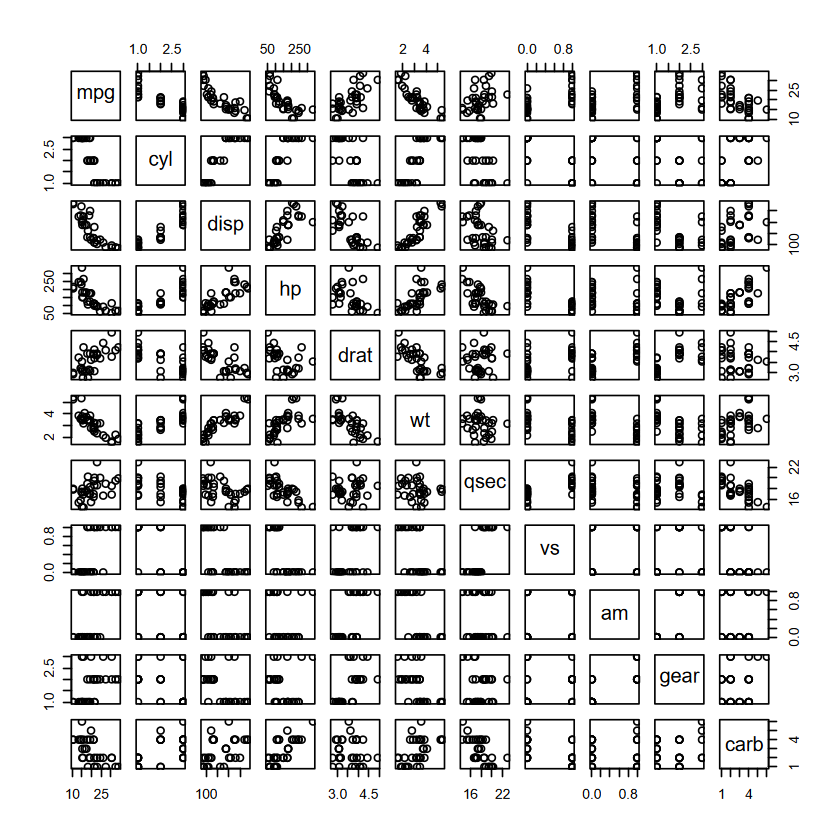

In [3]:
pairs(datos)

Modelo de efectos principales.

In [20]:
modelo_ep <- lm(mpg ~ ., data = datos)

summary(modelo_ep)


Call:
lm(formula = mpg ~ ., data = datos)

Residuals:
    Min      1Q  Median      3Q     Max 
-3.5087 -1.3584 -0.0948  0.7745  4.6251 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)  
(Intercept) 23.87913   20.06582   1.190   0.2525  
cyl6        -2.64870    3.04089  -0.871   0.3975  
cyl8        -0.33616    7.15954  -0.047   0.9632  
disp         0.03555    0.03190   1.114   0.2827  
hp          -0.07051    0.03943  -1.788   0.0939 .
drat         1.18283    2.48348   0.476   0.6407  
wt          -4.52978    2.53875  -1.784   0.0946 .
qsec         0.36784    0.93540   0.393   0.6997  
vs1          1.93085    2.87126   0.672   0.5115  
am1          1.21212    3.21355   0.377   0.7113  
gear4        1.11435    3.79952   0.293   0.7733  
gear5        2.52840    3.73636   0.677   0.5089  
carb2       -0.97935    2.31797  -0.423   0.6787  
carb3        2.99964    4.29355   0.699   0.4955  
carb4        1.09142    4.44962   0.245   0.8096  
carb6        4.47757    6.38406 

Modelo con interacción entre variables.

La interacción hp:am1 indica que el efecto de la potencia del motor (hp) sobre el consumo de combustible (mpg) dependiendo del tipo de transmisión (am).

```r 

In [4]:

modelo_interaccion <- lm(mpg ~ disp + hp*am + wt, data = datos)
summary(modelo_interaccion)



Call:
lm(formula = mpg ~ disp + hp * am + wt, data = datos)

Residuals:
    Min      1Q  Median      3Q     Max 
-3.4288 -1.5153 -0.6758  1.2990  5.2444 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept) 33.2908505  3.1224652  10.662 5.49e-11 ***
disp        -0.0004507  0.0112429  -0.040   0.9683    
hp          -0.0286722  0.0194256  -1.476   0.1520    
am1          3.5681721  2.4383897   1.463   0.1554    
wt          -3.0294082  1.1678861  -2.594   0.0154 *  
hp:am1      -0.0115192  0.0160392  -0.718   0.4790    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 2.605 on 26 degrees of freedom
Multiple R-squared:  0.8433,	Adjusted R-squared:  0.8132 
F-statistic: 27.99 on 5 and 26 DF,  p-value: 1.094e-09


Modelo saturado hasta interacciones de segundo orden. Por el número de variables, el modelo saturado es inservible.

In [5]:
modelo_saturado <- lm(mpg ~ .^2, data = datos)
summary(modelo_saturado)


Call:
lm(formula = mpg ~ .^2, data = datos)

Residuals:
ALL 32 residuals are 0: no residual degrees of freedom!

Coefficients: (93 not defined because of singularities)
              Estimate Std. Error t value Pr(>|t|)
(Intercept) -1.439e+02        NaN     NaN      NaN
cyl6        -3.468e+02        NaN     NaN      NaN
cyl8         4.999e+02        NaN     NaN      NaN
disp         7.802e-01        NaN     NaN      NaN
hp          -2.000e+00        NaN     NaN      NaN
drat        -6.019e+01        NaN     NaN      NaN
wt          -2.380e+01        NaN     NaN      NaN
qsec         2.092e+01        NaN     NaN      NaN
vs1          2.545e+01        NaN     NaN      NaN
am1          1.526e+02        NaN     NaN      NaN
gear4       -1.023e+02        NaN     NaN      NaN
gear5       -5.806e+01        NaN     NaN      NaN
carb2        3.001e+01        NaN     NaN      NaN
carb3        4.607e+01        NaN     NaN      NaN
carb4        2.479e+01        NaN     NaN      NaN
carb6       -7

Definamos un modelo para trabajar.

Notemos que el modelo incluye las variables `wt`, `hp` y `am` como predictores de `mpg`. 

Estas variables significan: 
- `mpg`: millas por galón (consumo de combustible)
- `wt`: peso del vehículo (en miles de libras)
- `hp`: potencia del motor (en caballos de fuerza)  
- `am`: tipo de transmisión (0 = automática, 1 = manual)

Algunas observaciones iniciales del resumen del modelo:

- El modelo tiene sentido, pues se rechaza la prueba F global, indicando que al menos una de las variables explicativas tiene un efecto significativo sobre `mpg`.

- Solo una variable no aporta información significativa al modelo (am1), sin embargo esto no implica que deba ser eliminada sin considerar el contexto del problema.


Interpretación de los coeficientes:

- El intercepto ($\beta_0 = 37.2851$) representa el valor esperado de `mpg` cuando `wt`, `hp` y `am1` son cero. Aunque en este caso, tener un peso y potencia de cero no es realista, el intercepto sirve como punto de referencia en el modelo.


- El coeficiente de `wt` ($\beta_1 = -5.3445$) indica que, manteniendo constantes `hp` y `am`, un aumento de 1 unidad en `wt` (1000 libras) se asocia con una disminución promedio de aproximadamente 5.34 millas por galón en `mpg`. Esto sugiere que vehículos más pesados tienden a tener un menor rendimiento de combustible.

- El coeficiente de `hp` ($\beta_2 = -0.0318$) sugiere que, manteniendo constantes `wt` y `am`, un aumento de 1 unidad en `hp` se asocia con una disminución promedio de aproximadamente 0.032 millas por galón en `mpg`. Esto indica que vehículos con mayor potencia tienden a consumir más combustible.



In [23]:
modelo <- lm(mpg ~ wt + hp + vs, data = datos)
summary(modelo)


Call:
lm(formula = mpg ~ wt + hp + vs, data = datos)

Residuals:
    Min      1Q  Median      3Q     Max 
-3.4667 -1.4857 -0.4296  1.0341  5.7384 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 35.38267    2.42564  14.587 1.31e-14 ***
wt          -3.78003    0.63985  -5.908 2.35e-06 ***
hp          -0.02542    0.01100  -2.312   0.0284 *  
vs1          1.36771    1.35296   1.011   0.3207    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 2.592 on 28 degrees of freedom
Multiple R-squared:  0.8329,	Adjusted R-squared:  0.815 
F-statistic: 46.52 on 3 and 28 DF,  p-value: 5.276e-11


Pruebas de hipótesis sobre los coeficientes: `glht` del paquete `multcomp`.

El director de la empresa automotriz está interesado en saber si se pueden hacer las siguientes afirmaciones:

1.- El efecto del peso (wt) es el doble del efecto de la potencia (hp).

2.- El efecto del tipo de motor (vs) equivale al efecto del peso dividido entre 4.

Además, obtener los intervalos de confianza para cada una de estas comparaciones.



In [ ]:
# Matriz de restricciones
# Orden de coeficientes: (Intercept), wt, hp, qsec, vs


library(multcomp)


# Orden de coeficientes:
# (Intercept), wt, hp, vs

K <- rbind(
  c(0, 1, -2, 0),      # β_wt - 2β_hp = 0
  c(0, -0.25, 0, 1)    # β_vs - 0.25β_wt = 0
)

# Prueba simultánea
test <- glht(modelo, linfct = K)


# resumen
summary(test)


# intervalos de confianza
confint(test)


	 Simultaneous Tests for General Linear Hypotheses

Fit: lm(formula = mpg ~ wt + hp + am, data = datos)

Linear Hypotheses:
       Estimate Std. Error t value Pr(>|t|)   
1 == 0  -2.8036     0.9185  -3.052  0.00899 **
2 == 0   2.8034     1.2212   2.295  0.05118 . 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
(Adjusted p values reported -- single-step method)



	 Simultaneous Confidence Intervals

Fit: lm(formula = mpg ~ wt + hp + am, data = datos)

Quantile = 2.3066
95% family-wise confidence level
 

Linear Hypotheses:
       Estimate lwr     upr    
1 == 0 -2.8036  -4.9223 -0.6849
2 == 0  2.8034  -0.0136  5.6203


Comparación de modelos anidados. `anova()` de R base.

In [14]:
# modelo reducido

M0 <- lm(mpg ~ wt + hp, data = mtcars)

anova(M0, modelo)

,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,29,195.0478,NA,NA,NA,NA
2,28,180.2911,1,14.75668,2.291778,0.1412682


Comparación de efectos: `allEffects` del paquete `effects`.


Call:
lm(formula = mpg ~ carb + cyl, data = datos)

Residuals:
   Min     1Q Median     3Q    Max 
-5.339 -1.354  0.000  2.068  7.061 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  26.8391     1.4004  19.165  4.7e-16 ***
carb2        -0.3217     1.7737  -0.181   0.8576    
carb3        -0.2457     2.8136  -0.087   0.9312    
carb4        -2.7783     2.0787  -1.337   0.1939    
carb6        -1.9022     3.8829  -0.490   0.6287    
carb8        -1.5457     3.9287  -0.393   0.6975    
cyl6         -5.2370     2.0713  -2.528   0.0184 *  
cyl8        -10.2935     1.8498  -5.565  1.0e-05 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 3.358 on 24 degrees of freedom
Multiple R-squared:  0.7596,	Adjusted R-squared:  0.6895 
F-statistic: 10.84 on 7 and 24 DF,  p-value: 4.18e-06


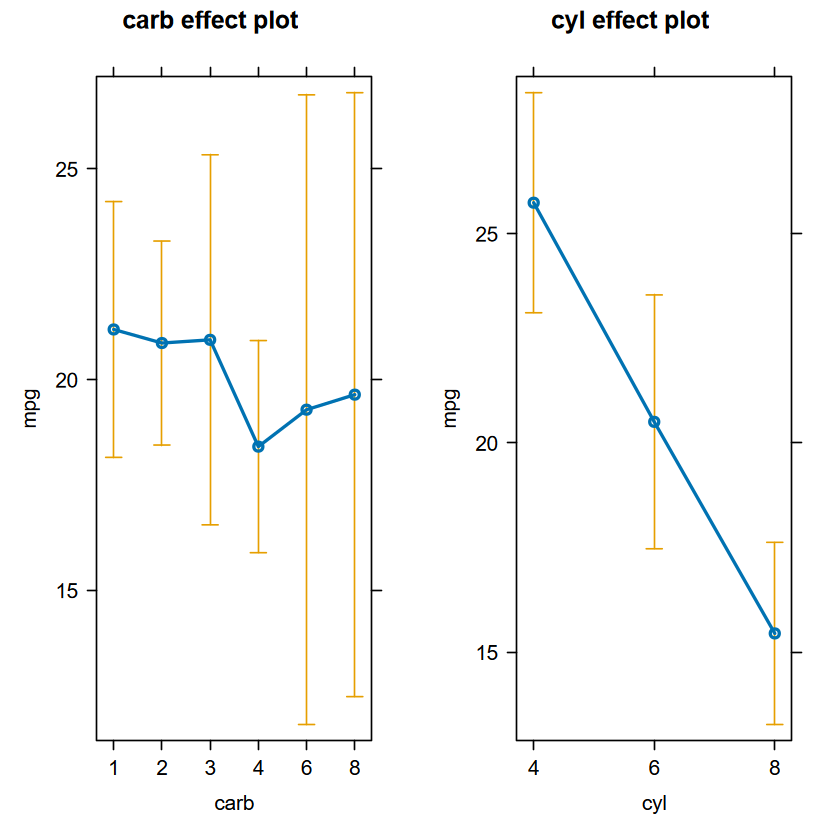

In [17]:
# Instalar si no lo tienes

library(effects)

modelo_efectos <- lm(mpg ~ carb + cyl , data = datos)

summary(modelo_efectos)

# Graficar todos los efectos
plot(allEffects(modelo_efectos))
